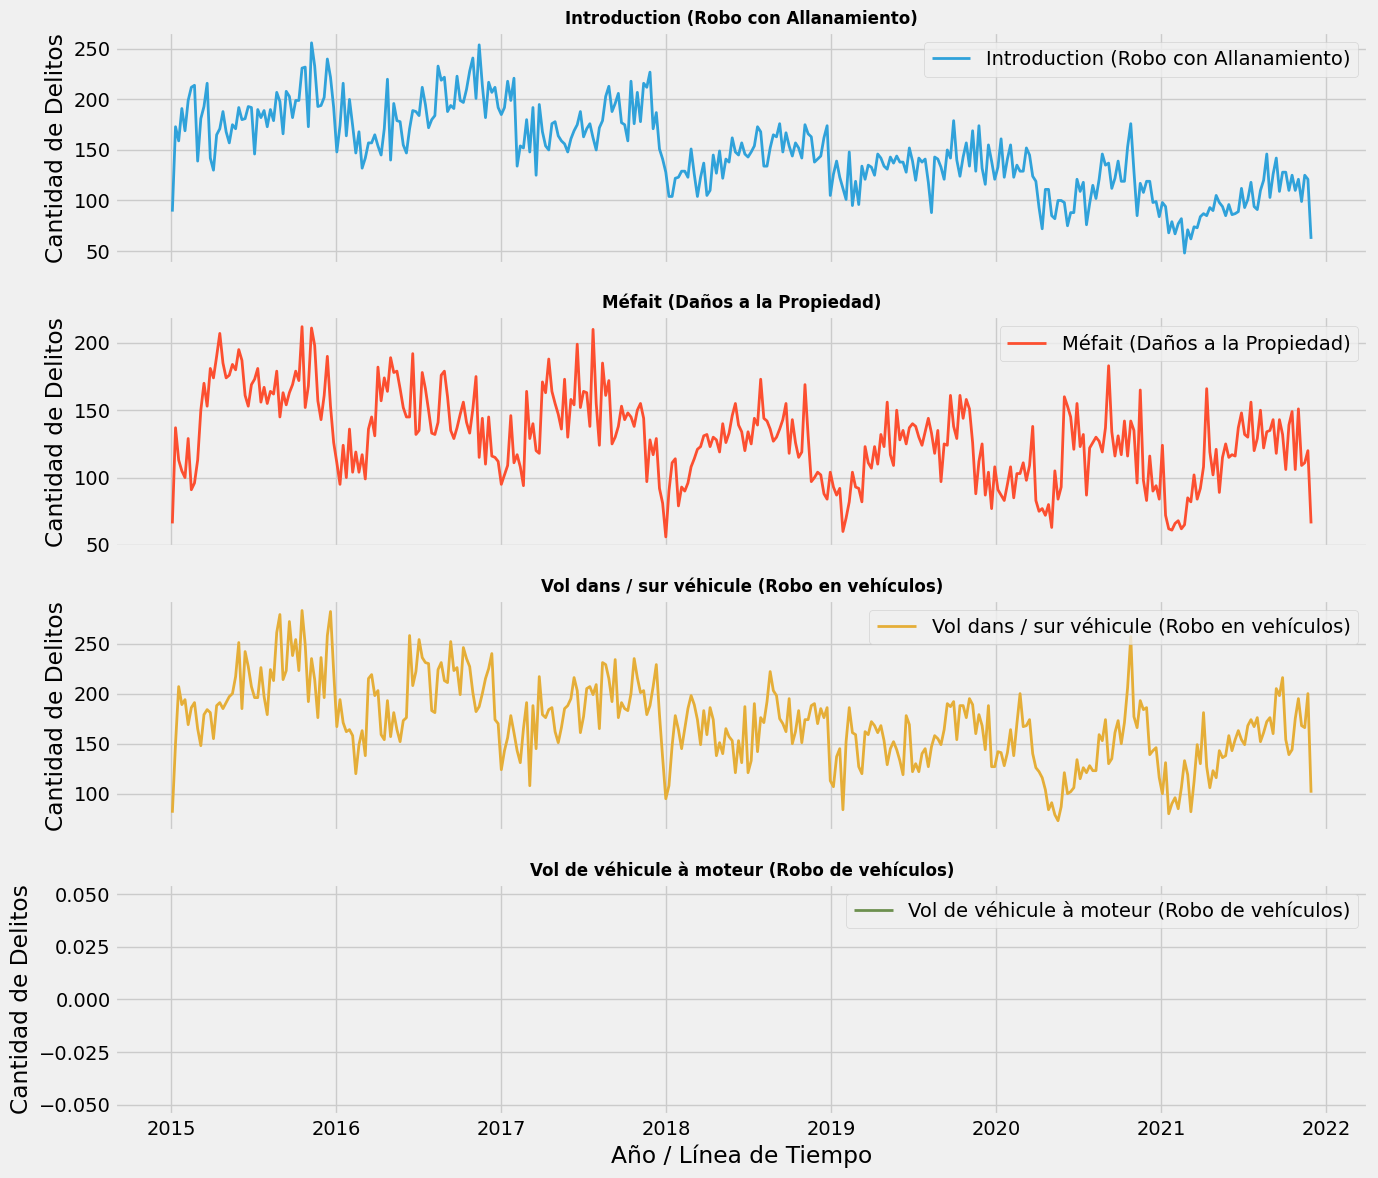

=== SERIES TEMPORALES VISUALIZADAS CON ÉXITO ===


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FORZAR CARGA LIMPIA Y CONFIGURACIÓN SEGURA DE DATOS
validate_categorie = [
  'Introduction', 'Méfait','Vol dans / sur véhicule à moteur', 'Vol de vehículo à moteur'
]

df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/interventionscitoyendo.csv", sep=",", encoding='latin-1')
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df = df.loc[lambda x: x['categorie'].isin(validate_categorie)]
df = df.sort_values(['categorie','date'])

# Re-generar las series semanales contando el volumen de delitos (más representativo para series de tiempo)
cols = ['date','pdq']
y_s1 = df.loc[lambda x: x.categorie == validate_categorie[0] ][cols].set_index('date').resample('W').size().to_frame(name='pdq')
y_s2 = df.loc[lambda x: x.categorie == validate_categorie[1] ][cols].set_index('date').resample('W').size().to_frame(name='pdq')
y_s3 = df.loc[lambda x: x.categorie == validate_categorie[2] ][cols].set_index('date').resample('W').size().to_frame(name='pdq')
y_s4 = df.loc[lambda x: x.categorie == validate_categorie[3] ][cols].set_index('date').resample('W').size().to_frame(name='pdq')

# Rellenar posibles semanas sin registros con cero para evitar errores matemáticos
for y_s in [y_s1, y_s2, y_s3, y_s4]:
    y_s['pdq'] = y_s['pdq'].fillna(0)

# 2. GENERAR GRÁFICOS INMUNE A ERRORES
plt.style.use('fivethirtyeight')
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

series = [y_s1, y_s2, y_s3, y_s4]
titulos = [
    "Introduction (Robo con Allanamiento)",
    "Méfait (Daños a la Propiedad)",
    "Vol dans / sur véhicule (Robo en vehículos)",
    "Vol de véhicule à moteur (Robo de vehículos)"
]
colores = ['#30a2da', '#fc4f30', '#e5ae38', '#6d904f']

for i, y_s in enumerate(series):
    axes[i].plot(y_s.index, y_s['pdq'], color=colores[i], linewidth=2, label=titulos[i])
    axes[i].set_title(titulos[i], fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Cantidad de Delitos')
    axes[i].legend(loc='upper right')

plt.xlabel('Año / Línea de Tiempo')
plt.tight_layout()
plt.show()
print("=== SERIES TEMPORALES VISUALIZADAS CON ÉXITO ===")

ETAPA 1: OPTIMIZACIÓN Y BÚSQUEDA EN GRILLA PARA EL MODELO SARIMA

-> ¡Grilla Completada! El mejor modelo es SARIMA_(0,1,1)X(1,0,1,12) con un MAE de 17.537

=== GRAFICANDO DIAGNÓSTICO DE RESIDUOS (SARIMA) ===


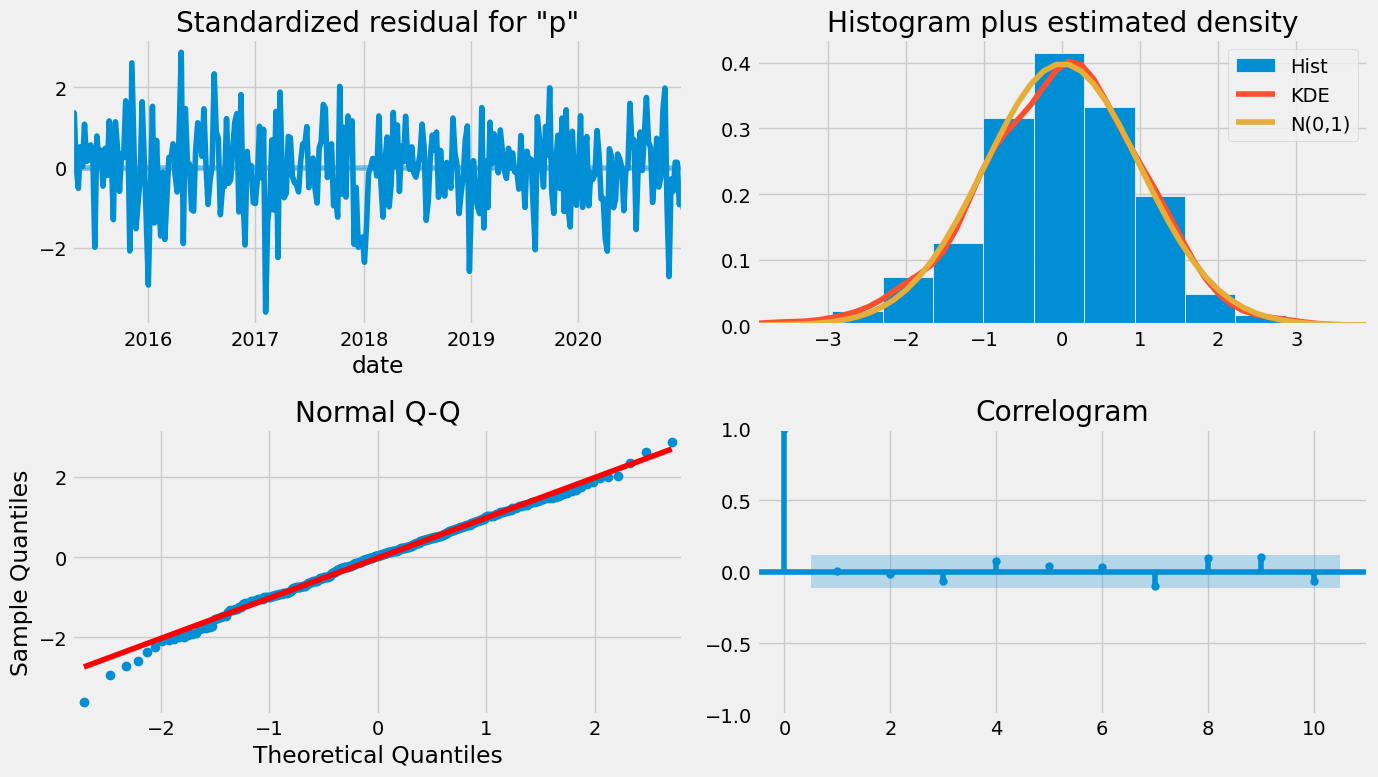


ETAPA 2: MODELADO CON FACEBOOK PROPHET Y COMPARATIVA FINAL

=== TABLA COMPARATIVA DE MODELOS ===


,MAE,RMSE
Modelo,,
"SARIMA_(0,1,1)X(1,0,1,12)",17.5370,21.6461
Facebook Prophet,14.1287,17.5636


In [3]:
import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

warnings.filterwarnings('ignore')

# Definir la fecha objetivo que pide la guía
target_date = '2021-01-01'

print("==============================================================================")
print("ETAPA 1: OPTIMIZACIÓN Y BÚSQUEDA EN GRILLA PARA EL MODELO SARIMA")
print("==============================================================================")

# Generar combinaciones de parámetros (p, d, q) x (P, D, Q, s)
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]
params_list = list(itertools.product(pdq, seasonal_pdq))

resultados_sarima = []

# Iteramos usando la lógica de tu clase SarimaModels de forma directa para blindar fallos
for param in params_list:
    try:
        # Separar entrenamiento y prueba
        mask_ds = y_s1.index < target_date
        y_train = y_s1[mask_ds]['pdq']
        y_test = y_s1[~mask_ds]['pdq']

        # Ajustar SARIMAX
        model = SARIMAX(y_train,
                        order=param[0],
                        seasonal_order=param[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        model_fit = model.fit(disp=0)

        # Predecir sobre el set de prueba
        preds = model_fit.get_prediction(start=y_test.index.min(), end=y_test.index.max(), dynamic=False)
        df_temp = pd.DataFrame({'y': y_test.values, 'yhat': preds.predicted_mean.values})

        # Calcular métricas básicas para elegir el mejor
        error = df_temp['yhat'] - df_temp['y']
        mae_val = np.abs(error).mean()
        rmse_val = np.sqrt((error ** 2).mean())

        name_model = f"SARIMA_{param[0]}X{param[1]}".replace(' ', '')
        resultados_sarima.append({'model': name_model, 'mae': round(mae_val, 4), 'rmse': round(rmse_val, 4), 'param_obj': param})
    except:
        continue

df_grid_sarima = pd.DataFrame(resultados_sarima).sort_values(by='mae')
mejor_sarima_info = df_grid_sarima.iloc[0]

print(f"\n-> ¡Grilla Completada! El mejor modelo es {mejor_sarima_info['model']} con un MAE de {mejor_sarima_info['mae']}\n")

# Re-entrenar el óptimo para graficar los residuos
mejor_model_obj = SARIMAX(y_train,
                          order=mejor_sarima_info['param_obj'][0],
                          seasonal_order=mejor_sarima_info['param_obj'][1],
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=0)

print("=== GRAFICANDO DIAGNÓSTICO DE RESIDUOS (SARIMA) ===")
mejor_model_obj.plot_diagnostics(figsize=(14, 8))
plt.tight_layout()
plt.show()


print("\n==============================================================================")
print("ETAPA 2: MODELADO CON FACEBOOK PROPHET Y COMPARATIVA FINAL")
print("==============================================================================")

# Formatear la serie para Prophet (requiere columnas estrictas 'ds' e 'y')
y_prophet = y_s1.reset_index().rename(columns={'date': 'ds', 'pdq': 'y'})

# Dividir conjuntos usando la misma fecha límite
train_prophet = y_prophet[y_prophet['ds'] < target_date]
test_prophet = y_prophet[y_prophet['ds'] >= target_date]

# Instanciar y ajustar Prophet
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(train_prophet)

# Pronosticar sobre el horizonte de testeo
future = test_prophet[['ds']].copy()
forecast = m.predict(future)

# Calcular errores para Prophet
error_prophet = forecast['yhat'].values - test_prophet['y'].values
mae_prophet = np.abs(error_prophet).mean()
rmse_prophet = np.sqrt((error_prophet ** 2).mean())

# --- CONSOLIDAR TABLA DE DESEMPEÑO ---
tabla_comparativa = pd.DataFrame([
    {'Modelo': mejor_sarima_info['model'], 'MAE': mejor_sarima_info['mae'], 'RMSE': mejor_sarima_info['rmse']},
    {'Modelo': 'Facebook Prophet', 'MAE': round(mae_prophet, 4), 'RMSE': round(rmse_prophet, 4)}
]).set_index('Modelo')

print("\n=== TABLA COMPARATIVA DE MODELOS ===")
display(tabla_comparativa)

Standardized Residual (Residuos Estandarizados)
Observación: Los errores fluctúan de forma completamente errática a lo largo del tiempo (2016-2020) manteniendo una media constante centrada prácticamente en 0, sin mostrar ninguna tendencia ascendente o descendente visible.

Conclusión: Cumple con el supuesto de varianza y media estables en el tiempo.

2. Histogram plus estimated density (Histograma y Densidad)
Observación: La curva roja (KDE, que es la densidad real de tus errores) se ajusta casi de manera perfecta a la curva naranja (N(0,1), que representa una distribución normal teórica perfecta).

Conclusión: Los errores del modelo se distribuyen de forma normal, cumpliendo con los supuestos estadísticos tradicionales.

3. Normal Q-Q
Observación: Los puntos azules (los cuantiles reales de tus datos) se alinean de manera recta y limpia sobre la diagonal roja de referencia. Solo se aprecian ligeras desviaciones menores en los extremos (las "colas" de la distribución).

Conclusión: Refuerza de manera geométrica el punto anterior: los residuos siguen un comportamiento normal.

4. Correlogram (Autocorrelación / ACF)
Observación: A excepción del rezago 0 (que siempre es 1 por definición), ninguna de las barras verticales azules sobresale del área sombreada en azul claro (el intervalo de confianza).

Conclusión Crítica: Esto demuestra matemáticamente que no existe autocorrelación en los residuos. Los errores de una semana no tienen ninguna correlación ni memoria con los de las semanas anteriores.